# 01 - EDA
Sections follow the build checklist:
1. Load and dtype fixes (arrays, IST datetime, canonical vehicle type)
2. Completeness + viability audit
3. Spatial EDA
4. Temporal EDA (IST-corrected)
5. Severity EDA
6. Device / reporter EDA (enforcement-quality add-on)

In [1]:
import sys, ast, json, re
from pathlib import Path
from itertools import combinations
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import pytz
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')
IST = pytz.timezone('Asia/Kolkata')
print('OK')

OK


## 1. Load and dtype fixes

In [2]:
RAW_CSV = ROOT / 'data' / 'raw' / 'violations.csv'
df = pd.read_csv(RAW_CSV, low_memory=False)
print(f'Shape: {df.shape}')
df.dtypes

Shape: (298450, 24)


id                               object
latitude                        float64
longitude                       float64
location                         object
vehicle_number                   object
vehicle_type                     object
description                     float64
violation_type                   object
offence_code                     object
created_datetime                 object
closed_datetime                 float64
modified_datetime                object
device_id                        object
created_by_id                    object
center_code                     float64
police_station                   object
data_sent_to_scita                 bool
junction_name                    object
action_taken_timestamp          float64
data_sent_to_scita_timestamp     object
updated_vehicle_number           object
updated_vehicle_type             object
validation_status                object
validation_timestamp             object
dtype: object

### 1a. Parse array columns
> Confirm whether doubled-quotes survive pandas CSV parsing. The safe_parse_list normalises both forms.

In [3]:
print('RAW violation_type repr (first 3):')
for v in df['violation_type'].head(3):
    print(' ', repr(v))

def safe_parse_list(val):
    if pd.isna(val):
        return []
    s = str(val).strip()
    s_norm = s.replace('""', '"')  # handle doubled-quote artifact
    for candidate in [s, s_norm]:
        try:
            r = json.loads(candidate)
            return r if isinstance(r, list) else [r]
        except Exception:
            pass
        try:
            r = ast.literal_eval(candidate)
            return r if isinstance(r, list) else [r]
        except Exception:
            pass
    return [s]

df['vtype_list']    = df['violation_type'].apply(safe_parse_list)
df['ocode_list']    = df['offence_code'].apply(safe_parse_list)
df['primary_vtype'] = df['vtype_list'].apply(lambda l: l[0].upper().strip() if l else None)
print('Parsed samples:')
print(df[['violation_type','vtype_list','primary_vtype']].head(3).to_string())

RAW violation_type repr (first 3):
  '["WRONG PARKING","PARKING NEAR ROAD CROSSING"]'
  '["NO PARKING"]'
  '["WRONG PARKING","PARKING IN A MAIN ROAD"]'
Parsed samples:
                                   violation_type                                   vtype_list  primary_vtype
0  ["WRONG PARKING","PARKING NEAR ROAD CROSSING"]  [WRONG PARKING, PARKING NEAR ROAD CROSSING]  WRONG PARKING
1                                  ["NO PARKING"]                                 [NO PARKING]     NO PARKING
2      ["WRONG PARKING","PARKING IN A MAIN ROAD"]      [WRONG PARKING, PARKING IN A MAIN ROAD]  WRONG PARKING


### 1b. Parse datetimes and convert to IST
> CRITICAL: created_datetime is UTC (+00). Bengaluru is IST (+5:30).
> A record at 00:28 UTC = 05:58 IST. Deriving hour from UTC shifts every peak window by 5.5 h.
> Use created_datetime (event time), NOT modified_datetime.

In [4]:
dt_cols = ['created_datetime','closed_datetime','modified_datetime',
           'action_taken_timestamp','data_sent_to_scita_timestamp','validation_timestamp']
for col in dt_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

df['created_at_ist'] = df['created_datetime'].dt.tz_convert(IST)
df['hour']        = df['created_at_ist'].dt.hour
df['day_of_week'] = df['created_at_ist'].dt.dayofweek
df['month']       = df['created_at_ist'].dt.month
df['date']        = df['created_at_ist'].dt.normalize()
df['is_weekend']  = df['day_of_week'].isin([5, 6])

r = df.iloc[0]
print(f'UTC : {r["created_datetime"]}')
print(f'IST : {r["created_at_ist"]}')
print(f'hour UTC={r["created_datetime"].hour}  ->  hour IST={r["hour"]}')
print(f'Parse failures: {df["created_at_ist"].isna().sum()}')
print(f'Date range (IST): {df["created_at_ist"].min()} -> {df["created_at_ist"].max()}')

UTC : 2023-11-20 00:28:46+00:00
IST : 2023-11-20 05:58:46+05:30
hour UTC=0  ->  hour IST=5.0
Parse failures: 5
Date range (IST): 2023-11-10 00:41:46+05:30 -> 2024-04-08 23:00:46+05:30


### 1c. Canonical vehicle type
> vehicle_type = raw submitted. updated_vehicle_type = post-validation (only for approved rows).
> Use updated where available, fall back to original.

In [5]:
both = df.dropna(subset=['updated_vehicle_type'])
disagree = both[
    both['vehicle_type'].str.upper().str.strip() !=
    both['updated_vehicle_type'].str.upper().str.strip()
]
print(f'Rows with both values  : {len(both):,}')
print(f'Rows that disagree     : {len(disagree):,}  ({len(disagree)/len(both)*100:.1f}%)')
print('Top disagreement pairs:')
print(disagree.groupby(['vehicle_type','updated_vehicle_type']).size()
      .sort_values(ascending=False).head(10).to_string())

df['vehicle_canon'] = (
    df['updated_vehicle_type'].fillna(df['vehicle_type'])
    .str.upper().str.strip()
)
print('\nCanonical vehicle_type distribution:')
print(df['vehicle_canon'].value_counts().head(15).to_string())

Rows with both values  : 173,196
Rows that disagree     : 6,169  (3.6%)
Top disagreement pairs:
vehicle_type    updated_vehicle_type
CAR             MAXI-CAB                899
                SCOOTER                 679
SCOOTER         MOTOR CYCLE             646
MOTOR CYCLE     SCOOTER                 466
MAXI-CAB        CAR                     299
CAR             MOTOR CYCLE             290
SCOOTER         CAR                     273
PASSENGER AUTO  SCOOTER                 250
                CAR                     164
MOPED           SCOOTER                 147

Canonical vehicle_type distribution:
vehicle_canon
SCOOTER                95440
CAR                    87638
MOTOR CYCLE            41269
PASSENGER AUTO         37568
MAXI-CAB               11836
LGV                     8290
GOODS AUTO              2974
MOPED                   2111
PRIVATE BUS             1656
VAN                     1524
TEMPO                   1288
BUS (BMTC/KSRTC)        1244
HGV                     117

### 1d. validation_status distinct values

In [6]:
print('All distinct values (incl. NaN):')
print(df['validation_status'].value_counts(dropna=False).to_string())
df['vs_norm'] = df['validation_status'].str.lower().str.strip()
n_approved = (df['vs_norm'] == 'approved').sum()
n_rejected = (df['vs_norm'] == 'rejected').sum()
n_null     = df['vs_norm'].isna().sum()
print(f'approved : {n_approved:,}  ({n_approved/len(df)*100:.1f}%)')
print(f'rejected : {n_rejected:,}  ({n_rejected/len(df)*100:.1f}%)')
print(f'null/NaN : {n_null:,}  ({n_null/len(df)*100:.1f}%)  <- unvalidated')

All distinct values (incl. NaN):
validation_status
NaN           125254
approved      115400
rejected       49754
created1        7044
processing       678
duplicate        320
approved : 115,400  (38.7%)
rejected : 49,754  (16.7%)
null/NaN : 125,254  (42.0%)  <- unvalidated


## 2. Completeness + viability audit

                              null_count  null_pct
closed_datetime                   298450    100.00
action_taken_timestamp            298450    100.00
description                       298450    100.00
data_sent_to_scita_timestamp      256289     85.87
validation_timestamp              125420     42.02
updated_vehicle_type              125254     41.97
validation_status                 125254     41.97
vs_norm                           125254     41.97
updated_vehicle_number            125254     41.97
center_code                        11260      3.77
location                            3041      1.02
day_of_week                            5      0.00
hour                                   5      0.00
month                                  5      0.00
created_at_ist                         5      0.00
primary_vtype                          0      0.00
ocode_list                             0      0.00
vtype_list                             0      0.00
date                           

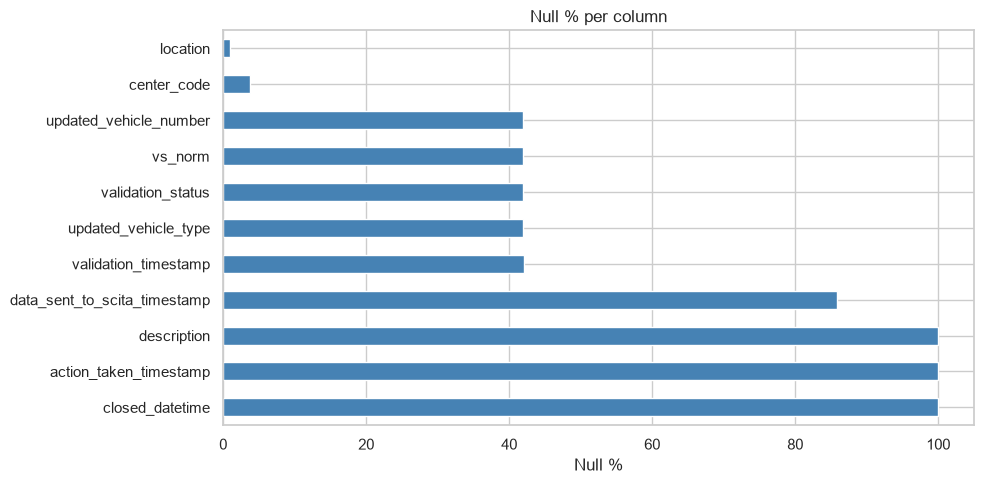

In [7]:
null_df = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct'  : (df.isnull().sum()/len(df)*100).round(2)
}).sort_values('null_pct', ascending=False)
print(null_df.to_string())
fig, ax = plt.subplots(figsize=(10,5))
null_df[null_df.null_pct > 0]['null_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Null %'); ax.set_title('Null % per column')
plt.tight_layout(); plt.show()

### 2b. junction_name sentinel -- 'No Junction' treated as missing

In [8]:
print('Distinct junction_name values (top 5):')
print(df['junction_name'].value_counts(dropna=False).head(5).to_string())
no_jn = df['junction_name'].isna() | df['junction_name'].str.strip().str.upper().eq('NO JUNCTION')
df['has_junction'] = ~no_jn
print(f'At named junction : {df["has_junction"].sum():,}  ({df["has_junction"].mean()*100:.1f}%)')
print(f'No/null           : {no_jn.sum():,}')

Distinct junction_name values (top 5):
junction_name
No Junction                        147880
BTP051 - Safina Plaza Junction      15449
BTP082 - KR Market Junction         11538
BTP040 - Elite Junction             10718
BTP044 - Sagar Theatre Junction     10549
At named junction : 150,565  (50.4%)
No/null           : 147,885


### 2c. vehicle_number viability -- are the plates synthetic?
> Plates like FKN00GL0000 -> FKN00GL0001 look like sequential anonymised IDs.
> Run this before committing to the repeat-offender add-on.

In [9]:
print('Sample plates:', df['vehicle_number'].head(10).tolist())
synth_pat = r'^FKN[A-Z0-9]+\d+$'
pct_synth = df['vehicle_number'].str.match(synth_pat, na=False).mean()*100
plate_vc = df['vehicle_number'].value_counts()
print(f'% matching synthetic pattern : {pct_synth:.1f}%')
print(f'Unique plates                : {plate_vc.shape[0]:,}')
print(f'Plates with >= 2 hits        : {(plate_vc>=2).sum():,}  ({(plate_vc>=2).sum()/plate_vc.shape[0]*100:.1f}%)')
print(f'Plates with >= 5 hits        : {(plate_vc>=5).sum():,}')
print('Top 10:', plate_vc.head(10).to_string())
if pct_synth > 90:
    print('VERDICT: plates are anonymised. Repeat-offender FREQUENCY stats still valid.')
    print('Cannot claim real-world identity -- note in pitch.')

Sample plates: ['FKN00GL0000', 'FKN00GL0001', 'FKN00GL0002', 'FKN00GL0003', 'FKN00GL0004', 'FKN00GL0005', 'FKN00GL0006', 'FKN00GL0007', 'FKN00GL0008', 'FKN00GL0009']
% matching synthetic pattern : 100.0%
Unique plates                : 231,890
Plates with >= 2 hits        : 35,587  (15.3%)
Plates with >= 5 hits        : 3,489
Top 10: vehicle_number
FKN00GL4424     55
FKN00GL3514     42
FKN00GL17863    41
FKN00GL9771     41
FKN00GL2906     35
FKN00GL15265    34
FKN00GL14092    34
FKN00GL1875     30
FKN00GL19337    30
FKN00GL9852     29
VERDICT: plates are anonymised. Repeat-offender FREQUENCY stats still valid.
Cannot claim real-world identity -- note in pitch.


## 3. Spatial EDA

In [10]:
LAT_MIN, LAT_MAX = 12.7, 13.2
LNG_MIN, LNG_MAX = 77.4, 77.8
df['lat'] = pd.to_numeric(df['latitude'],  errors='coerce')
df['lng'] = pd.to_numeric(df['longitude'], errors='coerce')
null_c = df[['lat','lng']].isna().any(axis=1).sum()
zero_c = ((df['lat']==0)|(df['lng']==0)).sum()
out_bb = (~df[['lat','lng']].isna().any(axis=1)) & (
    (df['lat']<LAT_MIN)|(df['lat']>LAT_MAX)|(df['lng']<LNG_MIN)|(df['lng']>LNG_MAX))
print(f'Null coords    : {null_c:,}')
print(f'Zero coords    : {zero_c:,}')
print(f'Out-of-bbox    : {out_bb.sum():,}  ({out_bb.sum()/len(df)*100:.2f}%)')
print(f'Lat range      : {df.lat.min():.4f} - {df.lat.max():.4f}')
print(f'Lng range      : {df.lng.min():.4f} - {df.lng.max():.4f}')
df_v = df[df['lat'].between(LAT_MIN, LAT_MAX) & df['lng'].between(LNG_MIN, LNG_MAX)].copy()
print(f'Valid in-bbox  : {len(df_v):,}')

Null coords    : 0
Zero coords    : 0
Out-of-bbox    : 168  (0.06%)
Lat range      : 12.8027 - 13.2937
Lng range      : 77.4426 - 77.7717
Valid in-bbox  : 298,282


### 3b. Fixed-camera stacks -- identical coordinate counts

Unique (lat,lng) pairs         : 208,980
Locations with >=50 violations : 9  (likely fixed cameras)
Top 20 repeated coordinates:
lat        lng      
12.999457  77.549582    119
12.876293  77.596530     97
12.934068  77.689769     82
12.999177  77.548612     80
12.999104  77.549582     67
12.934467  77.690405     57
12.934368  77.690132     54
12.999078  77.548443     53
12.930011  77.685171     53
12.966883  77.658087     49
12.933887  77.690752     40
12.929790  77.694947     40
13.071681  77.588985     39
12.937736  77.700794     36
12.926678  77.677832     33
12.934328  77.690610     33
13.034841  77.557343     31
12.934076  77.690721     31
12.994913  77.589723     31
12.981204  77.609571     31
-> DBSCAN eps rec: 0.0007-0.0009 deg (~80-100 m)


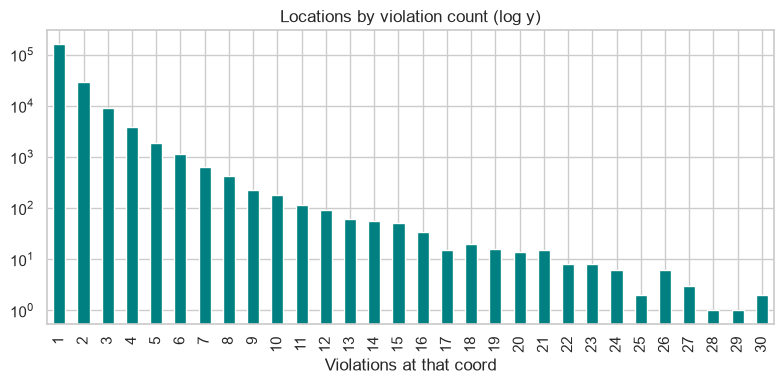

In [11]:
coord_vc = df_v.groupby(['lat','lng']).size().sort_values(ascending=False)
n_camera = (coord_vc >= 50).sum()
print(f'Unique (lat,lng) pairs         : {len(coord_vc):,}')
print(f'Locations with >=50 violations : {n_camera}  (likely fixed cameras)')
print('Top 20 repeated coordinates:')
print(coord_vc.head(20).to_string())
print('-> DBSCAN eps rec: 0.0007-0.0009 deg (~80-100 m)')
fig, ax = plt.subplots(figsize=(8,4))
coord_vc.value_counts().sort_index().head(30).plot(kind='bar', ax=ax, color='teal', logy=True)
ax.set_title('Locations by violation count (log y)'); ax.set_xlabel('Violations at that coord')
plt.tight_layout(); plt.show()

### 3c. Folium heatmap -- eyeball clusters before DBSCAN

In [12]:
sample = df_v.sample(min(8000, len(df_v)), random_state=42)
m = folium.Map(location=[12.9716, 77.5946], zoom_start=12, tiles='CartoDB positron')
HeatMap(sample[['lat','lng']].values.tolist(), radius=10, blur=15, max_zoom=13).add_to(m)
m.save('eda_heatmap.html')
print('Saved eda_heatmap.html')
m

Saved eda_heatmap.html


### 3d. Counts per station and junction

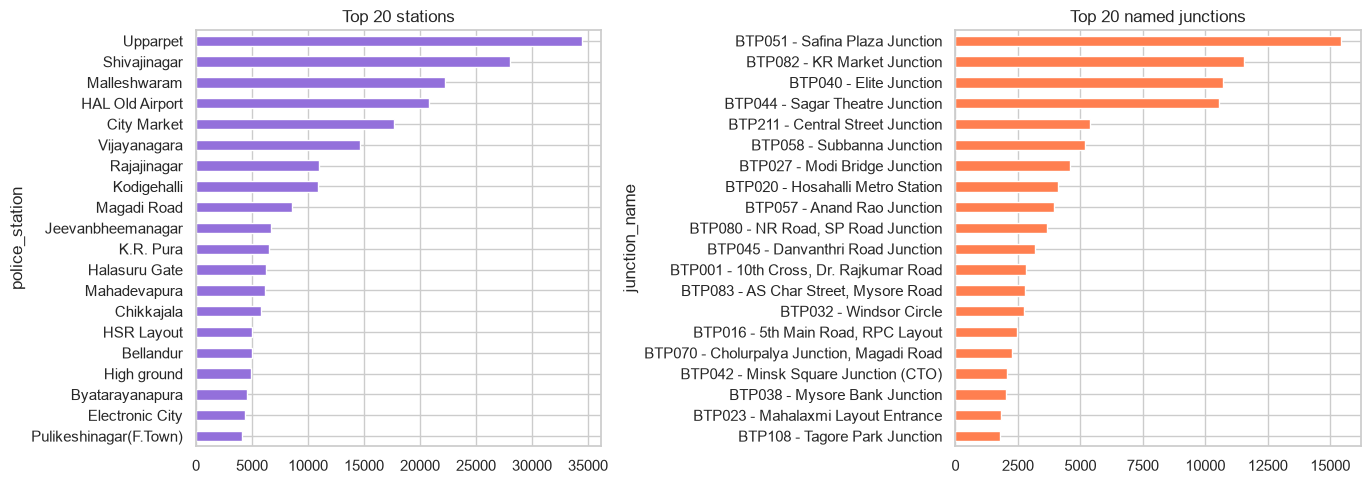

In [13]:
ps_vc = df_v['police_station'].value_counts()
jn_vc = df_v.loc[df_v['has_junction'],'junction_name'].value_counts()
fig, axes = plt.subplots(1,2,figsize=(14,5))
ps_vc.head(20).sort_values().plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Top 20 stations')
jn_vc.head(20).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 20 named junctions')
plt.tight_layout(); plt.show()

## 4. Temporal EDA -- IST-corrected

### 4a. Daily volume + gap check

Date range : 2023-11-10 -> 2024-04-08
Calendar days in range : 151
Days with data         : 151
Missing dates (gaps)   : 0


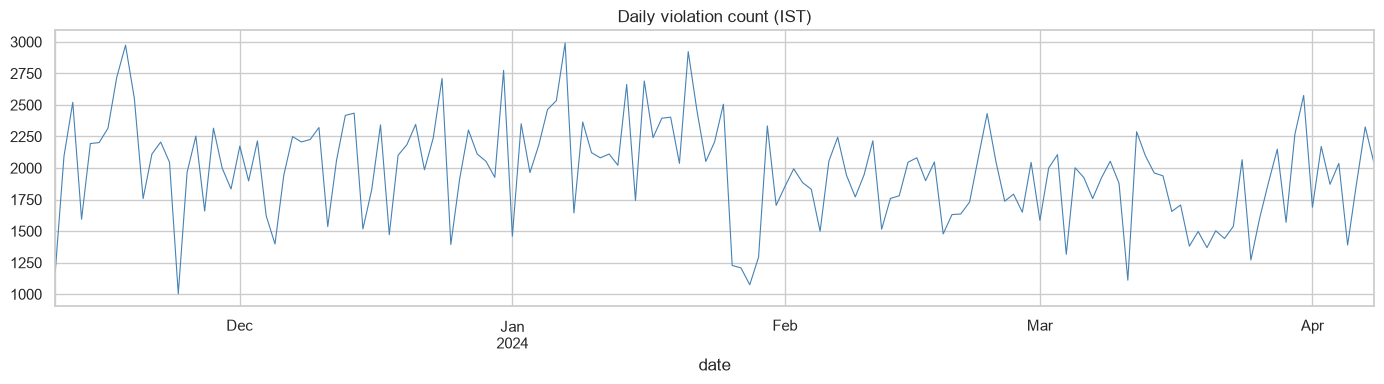

OK: sufficient continuity for time-series forecasting.


In [14]:
daily = df_v.groupby('date').size().rename('count')
print(f'Date range : {daily.index.min().date()} -> {daily.index.max().date()}')
print(f'Calendar days in range : {(daily.index.max()-daily.index.min()).days+1}')
print(f'Days with data         : {len(daily)}')
all_dates = pd.date_range(daily.index.min(), daily.index.max(), freq='D', tz=IST)
missing_dates = all_dates[~all_dates.isin(daily.index)]
print(f'Missing dates (gaps)   : {len(missing_dates)}')
if len(missing_dates): print(missing_dates.date)
fig, ax = plt.subplots(figsize=(14,4))
daily.plot(ax=ax, color='steelblue', linewidth=0.8)
ax.set_title('Daily violation count (IST)')
plt.tight_layout(); plt.show()
if len(missing_dates) > 14:
    print('WARNING: significant gaps -- interpolate or exclude gap windows from forecasting.')
else:
    print('OK: sufficient continuity for time-series forecasting.')

### 4b. Hour x weekday heatmap (IST)

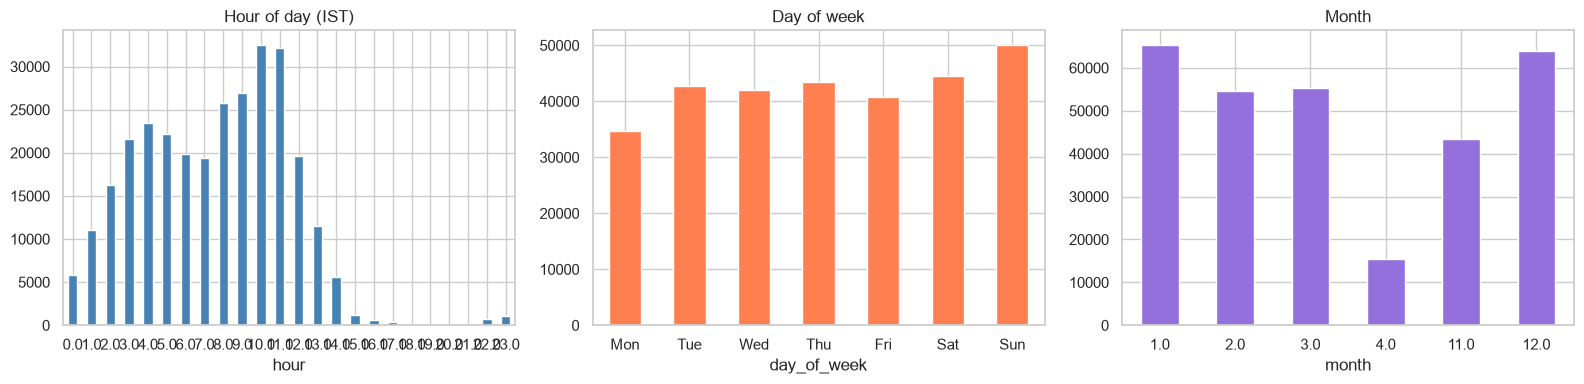

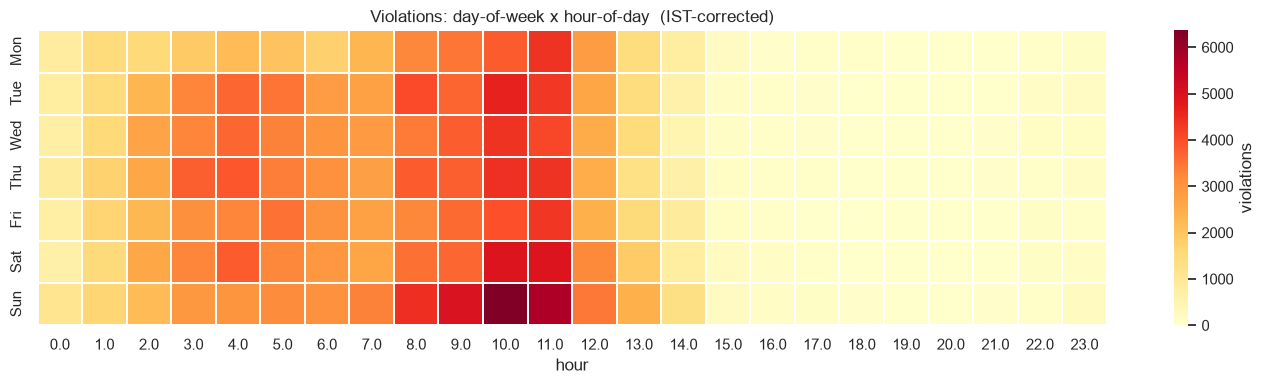

Peak hour (IST) : 10.0:00


TypeError: list indices must be integers or slices, not numpy.float64

In [15]:
DOW = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig, axes = plt.subplots(1,3,figsize=(16,4))
df_v['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Hour of day (IST)')
df_v['day_of_week'].value_counts().sort_index().rename(dict(enumerate(DOW))).plot(
    kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Day of week')
df_v['month'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumpurple')
axes[2].set_title('Month')
for ax in axes: ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

pivot = df_v.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
pivot.index = DOW
fig, ax = plt.subplots(figsize=(14,4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label':'violations'})
ax.set_title('Violations: day-of-week x hour-of-day  (IST-corrected)')
plt.tight_layout(); plt.show()

peak_h   = df_v['hour'].value_counts().idxmax()
peak_dow = df_v['day_of_week'].value_counts().idxmax()
print(f'Peak hour (IST) : {peak_h}:00')
print(f'Peak day        : {DOW[peak_dow]}')

## 5. Severity EDA

In [ ]:
vte = df_v['vtype_list'].explode().dropna()
vte = vte[vte.str.strip() != '']
vtype_vc = vte.str.upper().str.strip().value_counts()
print(f'Unique violation types: {vtype_vc.shape[0]}')
print(vtype_vc.to_string())
fig, ax = plt.subplots(figsize=(10,5))
vtype_vc.head(15).sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Violation type frequency (exploded)')
plt.tight_layout(); plt.show()

### 5b. Co-occurrence

In [ ]:
co = {}
for vlist in df_v['vtype_list']:
    cleaned = list({v.upper().strip() for v in vlist if v.strip()})
    if len(cleaned) > 1:
        for a,b in combinations(sorted(cleaned), 2):
            co[(a,b)] = co.get((a,b),0) + 1
co_df = (pd.DataFrame([(a,b,n) for (a,b),n in co.items()], columns=['type_a','type_b','count'])
         .sort_values('count', ascending=False))
print('Top 15 co-occurring pairs:')
print(co_df.head(15).to_string(index=False))

### 5c. Severity weight calibration

In [ ]:
SEVERITY_WEIGHTS = {
    'PARKING IN A MAIN ROAD': 3.0,
    'PARKING NEAR ROAD CROSSING': 2.5,
    'PARKING ON FOOTPATH': 2.0,
    'WRONG PARKING': 1.5,
    'NO PARKING': 1.0,
}
VEHICLE_WEIGHTS = {
    'TANKER':3.0,'TRUCK':2.5,'HGV':2.5,'BUS (BMTC/KSRTC)':2.5,'LORRY/GOODS VEHICLE':2.5,
    'LGV':2.0,'PRIVATE BUS':2.0,'MINI LORRY':2.0,
    'CAR':1.5,'MAXI-CAB':1.5,'JEEP':1.5,'VAN':1.5,'TEMPO':1.5,
    'PASSENGER AUTO':1.2,'GOODS AUTO':1.2,
    'SCOOTER':1.0,'MOTOR CYCLE':1.0,'MOPED':1.0,'TWO WHEELER':1.0,
}
DEFAULT_S = 1.0; DEFAULT_V = 1.0

df_v = df_v.copy()
df_v['severity_w'] = df_v['primary_vtype'].map(lambda v: SEVERITY_WEIGHTS.get(v, DEFAULT_S) if pd.notna(v) else DEFAULT_S)
df_v['vehicle_w']  = df_v['vehicle_canon'].map(lambda v: VEHICLE_WEIGHTS.get(v, DEFAULT_V) if pd.notna(v) else DEFAULT_V)

sw = df_v.groupby('primary_vtype').agg(count=('id','count'), weight=('severity_w','first'))\
         .sort_values('count', ascending=False)
print('Severity weight coverage:')
print(sw.to_string())
missing_sw = sw[sw['weight'] == DEFAULT_S]
if len(missing_sw):
    print(f'WARNING: {len(missing_sw)} types use DEFAULT weight -- add to config.py:')
    print(missing_sw['count'].to_string())
else:
    print('OK: all violation types have explicit weights.')

## 6. Device / reporter EDA

In [ ]:
print(f'Unique device_id     : {df_v["device_id"].nunique():,}')
print(f'Unique created_by_id : {df_v["created_by_id"].nunique():,}')
dev_vc = df_v['device_id'].value_counts()
usr_vc = df_v['created_by_id'].value_counts()
fig, axes = plt.subplots(1,2,figsize=(12,4))
dev_vc.head(30).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Violations per device (top 30)'); axes[0].tick_params(axis='x', rotation=90)
usr_vc.head(30).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Violations per reporter (top 30)'); axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()
print(f'Top device share   : {dev_vc.iloc[0]/len(df_v)*100:.1f}%')
print(f'Top reporter share : {usr_vc.iloc[0]/len(df_v)*100:.1f}%')

### 6b. Rejection rate by device and by police station

In [ ]:
validated = df_v.dropna(subset=['vs_norm'])
print(f'Rows with validation decision: {len(validated):,}  ({len(validated)/len(df_v)*100:.1f}%)')

def rej_stats(g):
    t = len(g); r = (g['vs_norm']=='rejected').sum()
    return pd.Series({'total':t,'rejected':r,'rejection_rate':round(r/t,4)})

rej_dev = validated.groupby('device_id').apply(rej_stats).sort_values('rejection_rate',ascending=False)
rej_stn = validated.groupby('police_station').apply(rej_stats).sort_values('rejection_rate',ascending=False)
print('Rejection rate by device (top 10):')
print(rej_dev.head(10).to_string())
print('Rejection rate by station (top 15):')
print(rej_stn.head(15).to_string())
fig, axes = plt.subplots(1,2,figsize=(14,5))
rej_stn.sort_values('rejection_rate')['rejection_rate'].tail(15).plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Rejection rate by station')
rej_dev.sort_values('rejection_rate')['rejection_rate'].head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Rejection rate by device')
plt.tight_layout(); plt.show()

## 7. EDA decisions summary

In [ ]:
print('=== PIPELINE DECISIONS FROM EDA ===')
print()
print('TEMPORAL')
print('  Use created_at_ist for ALL hour/weekday features -- NOT UTC')
print(f'  Peak hour: {peak_h}:00 IST | Peak day: {DOW[peak_dow]}')
print(f'  Date range: {daily.index.min().date()} -> {daily.index.max().date()} | Gaps: {len(missing_dates)}')
print()
print('COORDINATES')
print(f'  Drop {out_bb.sum():,} out-of-bbox rows')
print(f'  {n_camera} fixed-camera coords with >=50 violations -> use DBSCAN eps=0.0007-0.0009')
print()
print('VEHICLE TYPE')
print('  Use updated_vehicle_type where available (post-validation canonical value)')
print()
print('VALIDATION')
print(f'  Core analysis: approved only ({n_approved:,} rows)')
print()
print('REPEAT OFFENDERS')
print(f'  Plates are synthetic ({pct_synth:.0f}% match FKN* pattern)')
print(f'  Frequency stats valid; identity claims are not -- note in pitch')
print()
print('SEVERITY WEIGHTS to review in config.py (types using DEFAULT weight):')
if len(missing_sw):
    for t, row in missing_sw.sort_values('count', ascending=False).head(10).iterrows():
        print(f'  "{t}": ??,  # {int(row["count"]):,} occurrences')
else:
    print('  All covered.')